#  Pure Prompt-on-Demand Road Damage & Infrastructure Segmentation
### Murni SAM 3.1 / SAM 3 (Promptable Concept Segmentation) — Tanpa YOLO, Tanpa Koordinat Manual

Notebook ini melakukan segmentasi permukaan jalan & infrastruktur (**Pothole, Manhole, Traffic Sign, Road Crack**, atau kelas apa pun) secara **100% Pure SAM Prompt-on-Demand**, murni menggunakan kemampuan SAM tanpa detektor eksternal (YOLO/YOLO-World).

---

###  Apa yang Baru di Versi Ini?

1. **Benar-benar *Loosely Coupled* per Gambar**
   Deteksi tidak lagi bergantung pada koordinat `box`/`point` yang di-hardcode untuk satu gambar tertentu. Semua kelas didefinisikan sebagai **prompt teks** di satu dictionary (`CLASS_PROMPTS`). Ingin mengubah objek yang dideteksi? Cukup ubah teks prompt-nya — **tidak perlu mengubah kode inti sama sekali**, dan otomatis berlaku ke gambar/video apa pun.

2. **Default Model: SAM 3.1 → SAM 3 → SAM 2.1 (fallback otomatis)**
   Notebook mencoba memuat `sam3_1.pt` (SAM 3.1 — Object Multiplex, paling baru) terlebih dahulu, lalu `sam3.pt` (SAM 3), dan baru turun ke `sam2.1_t.pt` (SAM 2.1 Tiny, auto-download) jika keduanya tidak tersedia secara lokal.

3. **Presence-Aware Detection — Tidak Dipaksakan**
   Jika sebuah kelas memang tidak ada pada gambar/frame, sistem **tidak akan menampilkan atau menghitungnya**. Tidak ada mask atau box yang dipaksakan hanya karena prompt diberikan — sesuai dengan *presence head* SAM 3 yang membedakan "apakah konsep ada" dari "di mana lokasinya".

4. **Video Sepenuhnya Bisa Dikonfigurasi**
   Satu dictionary `VIDEO_CONFIG` mengatur: model apa yang dipakai, kelas apa saja yang dideteksi, ambang confidence, jumlah frame, resolusi proses — semuanya independen dari pipeline gambar.

5. **Satu Fungsi Inti untuk Semuanya**
   `run_prompt_detection()` dipakai baik untuk gambar tunggal maupun setiap frame video — sehingga perilaku selalu konsisten (*single source of truth*, tidak ada duplikasi logika).

---


## 1. Setup Environment & Instalasi

SAM 3 / SAM 3.1 (mode prompt teks) baru tersedia di Ultralytics **>= 8.3.237** lewat kelas `SAM3SemanticPredictor`. Sel di bawah memastikan versi yang terpasang cukup baru, lalu memuat seluruh dependensi.


In [1]:
# Jalankan sekali jika versi Ultralytics Anda masih lama (opsional, aman diulang)
# !pip install -U ultralytics


In [2]:
import os
import time
import threading
import queue
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

import ultralytics
from ultralytics import SAM

# SAM3SemanticPredictor & SAM3VideoSemanticPredictor baru ada di Ultralytics >= 8.3.237.
# Jika belum tersedia, notebook akan otomatis turun ke mode visual (box/point) SAM 2.1.
try:
    from ultralytics.models.sam import SAM3SemanticPredictor
    _SAM3_TEXT_PROMPT_READY = True
except ImportError:
    _SAM3_TEXT_PROMPT_READY = False

print(f"Ultralytics version   : {ultralytics.__version__}")
print(f"PyTorch version       : {torch.__version__}")
print(f"CUDA Available        : {torch.cuda.is_available()}")
print(f"SAM3SemanticPredictor : {'Tersedia ' if _SAM3_TEXT_PROMPT_READY else 'TIDAK tersedia  (upgrade: pip install -U ultralytics)'}")

if torch.cuda.is_available():
    DEVICE = 0
    print(f"GPU Device Name       : {torch.cuda.get_device_name(0)}")
    print(f"VRAM Total            : {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
else:
    DEVICE = "cpu"
    print("⚠️ CUDA tidak terdeteksi, inferensi akan berjalan di CPU (lambat untuk SAM 3/3.1).")


Ultralytics version   : 8.4.126
PyTorch version       : 2.13.0+cu130
CUDA Available        : True
SAM3SemanticPredictor : Tersedia 
GPU Device Name       : NVIDIA GeForce RTX 3080 Ti
VRAM Total            : 11.63 GB


## 2. Pemuatan Model SAM (Adaptif: SAM 3.1 → SAM 3 → SAM 2.1)

Urutan prioritas checkpoint bisa diubah bebas lewat `SAM_CHECKPOINT_PRIORITY`. Karena bobot `sam3_1.pt`/`sam3.pt` bersifat *gated* (harus diunduh manual dan disetujui lewat halaman model di Hugging Face — `facebook/sam3` / `facebook/sam3.1`), notebook ini akan:

- Memakainya **jika file tersebut sudah ada** di direktori kerja, dan mengaktifkan **mode `concept`** (deteksi berbasis prompt teks — ini mode default/yang direkomendasikan).
- Jika tidak ditemukan, otomatis turun ke `sam2.1_t.pt` (auto-download oleh Ultralytics) dengan **mode `visual`** (box/point manual, mode lama/legacy) — lihat catatan di bagian akhir notebook.

> 💡 Ingin memaksa pakai model tertentu? Cukup ubah urutan/isi `SAM_CHECKPOINT_PRIORITY` di sel berikut.


In [3]:
# Urutan prioritas checkpoint. Default: SAM 3.1 (Object Multiplex, tercepat untuk multi-objek)
# -> SAM 3 -> SAM 2.1 Tiny (fallback ringan, hemat VRAM, cocok untuk GPU kecil seperti RTX 3050).
SAM_CHECKPOINT_PRIORITY = ["sam3_1.pt", "sam3.pt", "sam2.1_t.pt"]


def resolve_sam_checkpoint(priority_list=SAM_CHECKPOINT_PRIORITY):
    """Pilih checkpoint pertama yang tersedia sesuai prioritas.

    Checkpoint keluarga SAM 3 (`sam3_1.pt`, `sam3.pt`) bersifat gated sehingga harus
    sudah ada secara lokal. Checkpoint SAM 2.1 selalu dianggap tersedia karena
    di-auto-download oleh Ultralytics saat pertama kali dipakai.
    """
    for ckpt in priority_list:
        if ckpt.startswith("sam2"):
            return ckpt
        if Path(ckpt).exists():
            return ckpt
    return priority_list[-1]


def get_sam_mode(checkpoint_name):
    """`concept` = deteksi berbasis prompt teks (SAM 3 / SAM 3.1); `visual` = box/point manual (SAM 2.1)."""
    return "concept" if checkpoint_name.startswith("sam3") else "visual"


SAM_CHECKPOINT = resolve_sam_checkpoint()
SAM_MODE = get_sam_mode(SAM_CHECKPOINT)

if SAM_MODE == "concept" and not _SAM3_TEXT_PROMPT_READY:
    print("⚠️ File SAM 3/3.1 ditemukan, tetapi `SAM3SemanticPredictor` tidak tersedia di versi Ultralytics ini.")
    print("   Jalankan `pip install -U ultralytics` lalu restart kernel. Sementara itu, turun ke mode visual SAM 2.1.")
    SAM_CHECKPOINT, SAM_MODE = "sam2.1_t.pt", "visual"

print(f"Checkpoint terpilih : {SAM_CHECKPOINT}")
print(f"Mode deteksi        : {'🅰 Prompt Teks / Concept (PCS) — direkomendasikan' if SAM_MODE == 'concept' else '🅱️ Visual Box/Point — legacy, perlu koordinat manual per gambar'}")

if SAM_MODE == "visual":
    print("\nCatatan: untuk mengaktifkan mode prompt teks, unduh `sam3_1.pt` atau `sam3.pt`")
    print("dari halaman model resmi di Hugging Face (facebook/sam3.1 atau facebook/sam3),")
    print("lalu taruh filenya di direktori kerja notebook ini dan jalankan ulang sel ini.")


Checkpoint terpilih : sam3_1.pt
Mode deteksi        : 🅰 Prompt Teks / Concept (PCS) — direkomendasikan


In [4]:
sam_predictor = None       # Instance SAM3SemanticPredictor (mode "concept")
sam_model_visual = None    # Instance SAM biasa (mode "visual")
SAM_ACTIVE_IMGSZ = None    # Construction-time image size for the active backend


def build_sam_backend(checkpoint, mode, conf=0.25, imgsz=1024, device=DEVICE):
    """Membangun backend SAM sesuai mode, dan menyimpannya ke variabel global.

    Dipanggil ulang otomatis apabila pipeline video meminta checkpoint atau
    construction-time imgsz yang berbeda dari backend concept yang sedang aktif.
    """
    global sam_predictor, sam_model_visual, SAM_ACTIVE_IMGSZ

    if mode == "concept":
        overrides = dict(
            conf=conf,
            task="segment",
            mode="predict",
            model=checkpoint,
            device=device,
            imgsz=imgsz,
            half=torch.cuda.is_available(),
            verbose=False,
            save=False,
        )
        sam_predictor = SAM3SemanticPredictor(overrides=overrides)
        sam_model_visual = None
        SAM_ACTIVE_IMGSZ = int(imgsz)
        return sam_predictor
    else:
        sam_model_visual = SAM(checkpoint)
        sam_predictor = None
        SAM_ACTIVE_IMGSZ = int(imgsz)
        return sam_model_visual


print(f"Memuat Pure SAM ({SAM_CHECKPOINT}, mode={SAM_MODE})...")
build_sam_backend(SAM_CHECKPOINT, SAM_MODE)
print(" Backend SAM siap dipakai untuk Prompt-on-Demand!")


Memuat Pure SAM (sam3_1.pt, mode=concept)...
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
 Backend SAM siap dipakai untuk Prompt-on-Demand!


## 3. Konfigurasi Kelas via Prompt Teks — Inti dari *Loose Coupling*

`CLASS_PROMPTS` adalah **satu-satunya tempat** yang perlu diubah untuk mengganti objek yang dideteksi. Setiap entri berisi:

- `text` — frasa benda (noun phrase) yang dicari SAM 3/3.1, mis. `"pothole on the road"`.
- `color` — warna overlay (BGR) untuk kelas tersebut.
- `label` — teks label yang ditampilkan di gambar/video.

Tidak ada koordinat, tidak ada nama file gambar tertentu di sini — dictionary ini berlaku untuk **gambar maupun video mana pun**, karena SAM 3/3.1 mencari konsepnya sendiri di seluruh frame.

> 💡 Menambah kelas baru = menambah satu entri di dictionary ini. Menghapus kelas = menghapus satu entri. Tidak ada bagian kode lain yang perlu disentuh.


In [5]:
CLASS_PROMPTS = {
    "pothole": {
        "text": "pothole on the road, damaged asphalt hole.",
        "label": "Pothole (Lubang Jalan)",
        "color": (0, 0, 255),        # Merah (BGR)
    },
    "manhole": {
        "text": "manhole cover, sewer cover on the road, either circle or square or rectangular, usually metal or concrete.",
        "label": "Manhole (Tutup Got)",
        "color": (0, 255, 0),        # Hijau (BGR)
    },
    "road_crack": {
        "text": "Crack lines on road",
        "label": "Road Crack (Retakan Aspal)",
        "color": (255, 0, 0),        # Biru (BGR)
    },
    "traffic_sign": {
        "text": "traffic sign",
        "label": "Traffic Sign (Rambu Jalan)",
        "color": (0, 255, 255),      # Kuning (BGR)
    },

    # "water puddle": {
    #     "text": "water inside pothole or puddle, occasionally brown colour",
    #     "label": "Water Puddle",
    #     "color": (255, 0, 255),   # Magenta
    # },
    # "fallen_leaves": {
    #     "text": "leaves on the ground",
    #     "label": "Fallen Leaves",
    #     "color": (255, 255, 0),   # Cyan
    # },
}

CONFIDENCE_THRESHOLD = 0.2  # Ambang confidence global untuk mode "concept"

print(" CLASS_PROMPTS aktif:")
for name, cfg in CLASS_PROMPTS.items():
    print(f"  • '{name}' → prompt: \"{cfg['text']}\"  |  label: {cfg['label']}")


 CLASS_PROMPTS aktif:
  • 'pothole' → prompt: "pothole on the road, damaged asphalt hole."  |  label: Pothole (Lubang Jalan)
  • 'manhole' → prompt: "manhole cover, sewer cover on the road, either circle or square or rectangular, usually metal or concrete."  |  label: Manhole (Tutup Got)
  • 'road_crack' → prompt: "Crack lines on road"  |  label: Road Crack (Retakan Aspal)
  • 'traffic_sign' → prompt: "traffic sign"  |  label: Traffic Sign (Rambu Jalan)


## 4. Fungsi Inti Deteksi & Visualisasi (Core Engine)

Semua pipeline di bawah (gambar tunggal, pengujian per kelas, unified multi-prompt, dan video) memanggil **satu fungsi yang sama**: `run_prompt_detection()`. Fungsi ini otomatis memilih backend (`concept` atau `visual`) sesuai `SAM_MODE`, dan **hanya mengembalikan kelas yang benar-benar terdeteksi** — kelas yang tidak ditemukan pada gambar akan dilewati begitu saja, tidak dipaksakan.


In [ ]:
def _extract_instances(result):
    """Extract masks, confidence and optional class ids from one Results object."""
    if result is None:
        return None, None, None
    masks_obj = getattr(result, "masks", None)
    if masks_obj is None or getattr(masks_obj, "data", None) is None or len(masks_obj.data) == 0:
        return None, None, None

    # This transfer intentionally happens once per frame, after all text prompts
    # have been evaluated together by SAM 3/3.1.
    masks = masks_obj.data.cpu().numpy()
    boxes_obj = getattr(result, "boxes", None)
    if boxes_obj is not None and getattr(boxes_obj, "conf", None) is not None:
        confs = boxes_obj.conf.cpu().numpy()
    else:
        confs = np.ones(len(masks), dtype=np.float32)

    if boxes_obj is not None and getattr(boxes_obj, "cls", None) is not None:
        class_ids = boxes_obj.cls.cpu().numpy().astype(np.int64)
    else:
        class_ids = None
    return masks, confs, class_ids


_SAM_TMP_FRAME_PATH = Path(".sam3_tmp_frame.jpg")


def _sam_set_image(predictor, image):
    """Set one image. Supports ndarray directly, with a path fallback for older versions."""
    try:
        predictor.set_image(image)
    except Exception:
        cv2.imwrite(str(_SAM_TMP_FRAME_PATH), image)
        predictor.set_image(str(_SAM_TMP_FRAME_PATH))


def detect_concept_by_text(image_bgr, class_prompts, conf_threshold=CONFIDENCE_THRESHOLD):
    """SAM 3/3.1 concept segmentation with ONE GPU call for ALL text prompts.

    The CLASS_PROMPTS interface stays unchanged. A separate-prompt fallback is
    retained for Ultralytics builds whose batched result shape/class-id behavior
    is incompatible with the expected boxes.cls mapping.
    """
    if not class_prompts:
        return {}

    _sam_set_image(sam_predictor, image_bgr)
    class_names = list(class_prompts.keys())
    texts = [class_prompts[name]["text"] for name in class_names]

    def build_detections_from_result(result, names):
        masks, confs, class_ids = _extract_instances(result)
        # Ultralytics returns masks=None and zero boxes when no concept is present.
        # This is a valid empty result, not a reason to run every prompt again.
        if masks is None:
            boxes = getattr(result, "boxes", None)
            if boxes is not None and len(boxes) == 0:
                return {}, np.empty(0, dtype=np.int64)
            return None, class_ids
        if class_ids is None:
            return None, class_ids

        if class_ids.size and int(class_ids.max()) >= len(names):
            print("⚠️ Batched SAM returned an out-of-range boxes.cls index; falling back to separate prompts.")
            return None, class_ids
        if class_ids.size and int(class_ids.min()) < 0:
            print("⚠️ Batched SAM returned a negative boxes.cls index; falling back to separate prompts.")
            return None, class_ids

        detections_out = {}
        for class_idx, cls_name in enumerate(names):
            keep = (class_ids == class_idx) & (confs >= conf_threshold)
            if not keep.any():
                continue
            cfg = class_prompts[cls_name]
            detections_out[cls_name] = {
                "masks": masks[keep],
                "confidences": confs[keep],
                "label": cfg.get("label", cls_name),
                "color": cfg.get("color", (0, 0, 255)),
            }
        return detections_out, class_ids

    try:
        raw = sam_predictor(text=texts)
    except Exception as e:
        print(f"⚠️ Multi-prompt SAM inference gagal, fallback ke prompt terpisah: {e}")
        raw = None

    if raw is not None:
        results = raw if isinstance(raw, (list, tuple)) else [raw]
        result = results[0] if results else None
        detections, class_ids = (
            build_detections_from_result(result, class_names)
            if result is not None else (None, None)
        )
        if detections is not None:
            return detections

        # Compatibility fallback: one Results object per prompt.
        if len(results) == len(class_names):
            print("ℹ️ Using per-prompt Results compatibility fallback.")
            detections_fallback = {}
            for idx, cls_name in enumerate(class_names):
                m, c, _ = _extract_instances(results[idx])
                if m is None:
                    continue
                keep = c >= conf_threshold
                if not keep.any():
                    continue
                cfg = class_prompts[cls_name]
                detections_fallback[cls_name] = {
                    "masks": m[keep],
                    "confidences": c[keep],
                    "label": cfg.get("label", cls_name),
                    "color": cfg.get("color", (0, 0, 255)),
                }
            return detections_fallback

    # Last-resort fallback: preserve the known-working independent-prompt path.
    detections = {}
    for cls_name in class_names:
        cfg = class_prompts[cls_name]
        try:
            raw_one = sam_predictor(text=[cfg["text"]])
        except Exception as e:
            print(f"⚠️ Prompt '{cfg['text']}' (kelas '{cls_name}') gagal dijalankan: {e}")
            continue

        result_one = raw_one[0] if isinstance(raw_one, (list, tuple)) else raw_one
        masks, confs, _ = _extract_instances(result_one)
        if masks is None:
            continue

        keep = confs >= conf_threshold
        if not keep.any():
            continue

        detections[cls_name] = {
            "masks": masks[keep],
            "confidences": confs[keep],
            "label": cfg.get("label", cls_name),
            "color": cfg.get("color", (0, 0, 255)),
        }
    return detections


def detect_visual_by_geometry(image_bgr, class_prompts, device=DEVICE):
    """Legacy SAM 2.1 visual mode. Kept unchanged for fallback compatibility."""
    detections = {}
    for cls_name, cfg in class_prompts.items():
        boxes = cfg.get("boxes")
        points = cfg.get("points")
        if not boxes and not points:
            continue

        res = sam_model_visual.predict(
            source=image_bgr,
            bboxes=boxes,
            points=points,
            labels=cfg.get("point_labels", [1] * len(points) if points else None),
            retina_masks=True,
            verbose=False,
            device=device,
        )[0]

        masks, confs, _ = _extract_instances(res)
        if masks is None:
            continue

        detections[cls_name] = {
            "masks": masks,
            "confidences": confs,
            "label": cfg.get("label", cls_name),
            "color": cfg.get("color", (0, 0, 255)),
        }
    return detections


def run_prompt_detection(image_bgr, class_prompts, conf_threshold=CONFIDENCE_THRESHOLD, device=DEVICE):
    """Single entry point for image and video detection."""
    if SAM_MODE == "concept":
        return detect_concept_by_text(image_bgr, class_prompts, conf_threshold)
    return detect_visual_by_geometry(image_bgr, class_prompts, device)


print(" Multi-prompt SAM detection ready: one image encode + one call for all text classes.")


In [7]:
def render_detections(image_bgr, detections):
    """Render masks/contours/labels with all per-instance image work ROI-confined.

    The blend remains sequential and additive (`overlay * 1.0 + color * 0.45`),
    preserving the original overlap semantics. Labels are drawn on the full
    overlay at the same point in the per-instance order, so later masks/contours
    retain the original ability to overwrite earlier label pixels.
    """
    h, w = image_bgr.shape[:2]
    overlay = image_bgr.copy()
    records = []

    for cls_name, det in detections.items():
        color = det["color"]
        label = det["label"]

        for i, mask in enumerate(det["masks"]):
            mask_bin = (mask > 0.5).astype(np.uint8)
            if mask_bin.shape != (h, w):
                mask_bin = cv2.resize(
                    mask_bin, (w, h), interpolation=cv2.INTER_NEAREST
                )

            conf_val = float(det["confidences"][i]) if i < len(det["confidences"]) else None

            x, y, bw, bh = cv2.boundingRect(mask_bin)
            pixel_area = int(cv2.countNonZero(mask_bin))

            if bw > 0 and bh > 0 and pixel_area > 0:
                # A thickness-2 contour can touch one pixel outside the mask
                # bounding box. Pad the ROI while keeping the mask itself unchanged.
                pad = 2
                x0 = max(0, x - pad)
                y0 = max(0, y - pad)
                x1 = min(w, x + bw + pad)
                y1 = min(h, y + bh + pad)

                sub_mask = mask_bin[y0:y1, x0:x1]
                sub_img = overlay[y0:y1, x0:x1]

                layer = np.empty_like(sub_img)
                layer[:] = color
                blended = cv2.addWeighted(sub_img, 1.0, layer, 0.45, 0)
                cv2.copyTo(blended, sub_mask, sub_img)

                contours, _ = cv2.findContours(
                    sub_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
                )
                cv2.drawContours(sub_img, contours, -1, color, 2)

                conf_txt = f" {conf_val * 100:.0f}%" if conf_val is not None else ""
                # Keep labels on the full overlay, preserving the original
                # per-instance draw order and avoiding ROI clipping.
                cv2.putText(
                    overlay,
                    f"{label}{conf_txt}",
                    (x, max(20, y - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.55,
                    (255, 255, 255),
                    2,
                )

            records.append({
                "class": cls_name,
                "label": label,
                "instance": i + 1,
                "pixel_area": pixel_area,
                "area_percent": (pixel_area / (h * w)) * 100.0,
                "confidence": conf_val,
            })

    return overlay, records


def show_coordinate_helper(image_path, title="Panduan Koordinat Gambar"):
    """Utilitas opsional: menampilkan gambar dengan grid piksel. Hanya diperlukan
    untuk mode legacy (visual box/point); pada mode 'concept' tidak dibutuhkan lagi
    karena tidak ada koordinat yang harus ditentukan manual.
    """
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        print(f" Gambar tidak ditemukan: {image_path}")
        return
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.title(f"{title} (Lebar: {w}px, Tinggi: {h}px)", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.4, color="yellow")
    plt.xlabel("Koordinat X (piksel)")
    plt.ylabel("Koordinat Y (piksel)")
    plt.show()


print(" Fungsi 'render_detections' dan 'show_coordinate_helper' siap digunakan!")


 Fungsi 'render_detections' dan 'show_coordinate_helper' siap digunakan!


## 5. Pengujian pada Gambar — Otomatis, Tanpa Koordinat per Gambar

Loop di bawah berjalan untuk **semua gambar** di `TEST_IMAGES` dan **semua kelas** di `CLASS_PROMPTS` sekaligus — karena prompt-nya berbasis teks, tidak ada penyesuaian koordinat yang dibutuhkan per gambar baru. Kelas yang tidak ditemukan pada suatu gambar akan dilaporkan sebagai "tidak ditemukan", bukan dipaksakan muncul.


Ultralytics 8.4.126 🚀 Python-3.14.4 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3080 Ti, 11905MiB)


/home/bondry/miky/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]


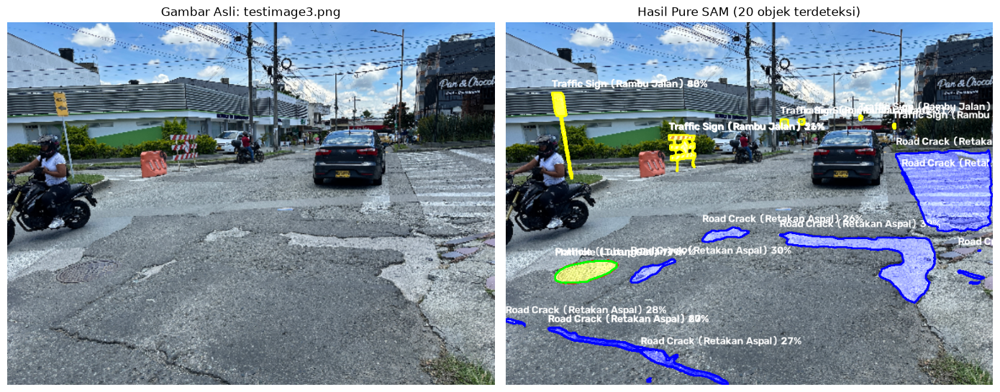

 Kelas terdeteksi pada 'testimage3.png': ['manhole', 'pothole', 'road_crack', 'traffic_sign']
    • Pothole (Lubang Jalan) #1: 2,454 px (0.56% dari gambar), confidence=0.69
    • Manhole (Tutup Got) #1: 2,384 px (0.54% dari gambar), confidence=0.77
    • Road Crack (Retakan Aspal) #1: 3,031 px (0.69% dari gambar), confidence=0.60
    • Road Crack (Retakan Aspal) #2: 8,582 px (1.95% dari gambar), confidence=0.39
    • Road Crack (Retakan Aspal) #3: 871 px (0.20% dari gambar), confidence=0.30
    • Road Crack (Retakan Aspal) #4: 174 px (0.04% dari gambar), confidence=0.29
    • Road Crack (Retakan Aspal) #5: 147 px (0.03% dari gambar), confidence=0.28
    • Road Crack (Retakan Aspal) #6: 1,569 px (0.36% dari gambar), confidence=0.27
    • Road Crack (Retakan Aspal) #7: 1,129 px (0.26% dari gambar), confidence=0.27
    • Road Crack (Retakan Aspal) #8: 950 px (0.22% dari gambar), confidence=0.26
    • Road Crack (Retakan Aspal) #9: 15,010 px (3.41% dari gambar), confidence=0.25
    • Road 

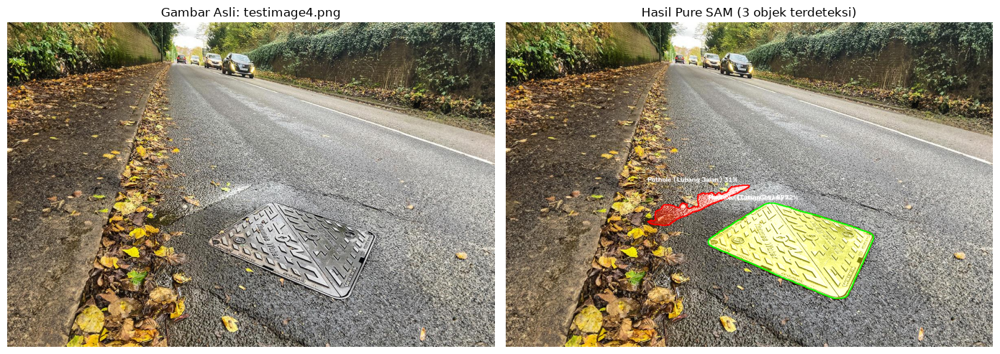

 Kelas terdeteksi pada 'testimage4.png': ['manhole', 'pothole']
➖ Tidak ditemukan (dilewati, bukan dipaksakan): ['road_crack', 'traffic_sign']
    • Pothole (Lubang Jalan) #1: 56,138 px (5.85% dari gambar), confidence=0.72
    • Pothole (Lubang Jalan) #2: 6,436 px (0.67% dari gambar), confidence=0.31
    • Manhole (Tutup Got) #1: 55,756 px (5.81% dari gambar), confidence=0.89
------------------------------------------------------------
WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]


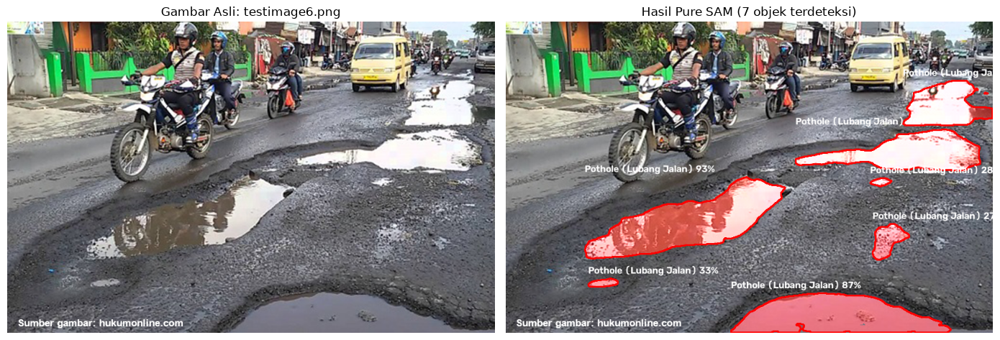

 Kelas terdeteksi pada 'testimage6.png': ['pothole']
➖ Tidak ditemukan (dilewati, bukan dipaksakan): ['manhole', 'road_crack', 'traffic_sign']
    • Pothole (Lubang Jalan) #1: 22,221 px (5.05% dari gambar), confidence=0.93
    • Pothole (Lubang Jalan) #2: 12,753 px (2.90% dari gambar), confidence=0.90
    • Pothole (Lubang Jalan) #3: 17,841 px (4.06% dari gambar), confidence=0.87
    • Pothole (Lubang Jalan) #4: 7,832 px (1.78% dari gambar), confidence=0.75
    • Pothole (Lubang Jalan) #5: 551 px (0.13% dari gambar), confidence=0.33
    • Pothole (Lubang Jalan) #6: 353 px (0.08% dari gambar), confidence=0.28
    • Pothole (Lubang Jalan) #7: 2,221 px (0.50% dari gambar), confidence=0.27
------------------------------------------------------------
WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]


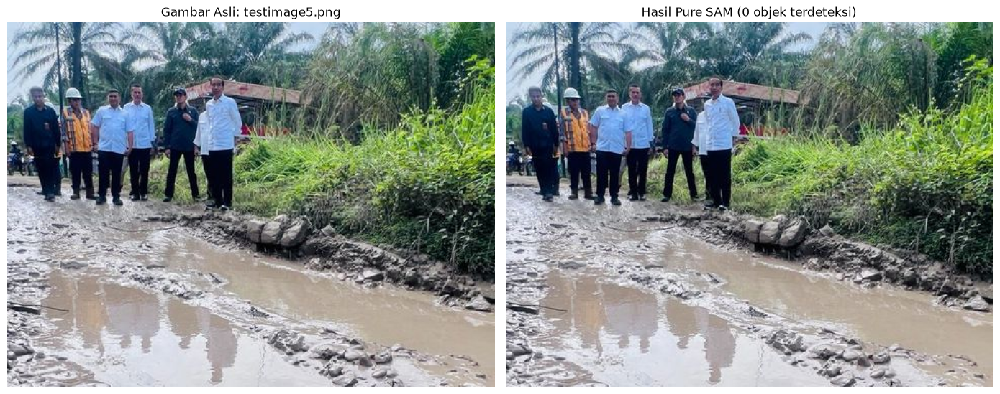

 Kelas terdeteksi pada 'testimage5.png': (tidak ada)
➖ Tidak ditemukan (dilewati, bukan dipaksakan): ['pothole', 'manhole', 'road_crack', 'traffic_sign']
------------------------------------------------------------


In [8]:
TEST_IMAGES = ["testimage3.png", "testimage4.png", "testimage6.png","testimage5.png"]
TEST_IMAGES = [p for p in TEST_IMAGES if Path(p).exists()]

if not TEST_IMAGES:
    print(" Tidak ada file pada TEST_IMAGES yang ditemukan di direktori kerja.")
    print("   Tambahkan nama file gambar Anda ke list TEST_IMAGES di atas.")

for img_path in TEST_IMAGES:
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f" Gagal membaca: {img_path}")
        continue

    detections = run_prompt_detection(img_bgr, CLASS_PROMPTS)
    overlay, records = render_detections(img_bgr, detections)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Gambar Asli: {img_path}", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Hasil Pure SAM ({len(records)} objek terdeteksi)", fontsize=12)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    found_classes = sorted(set(r["class"] for r in records))
    missing_classes = [c for c in CLASS_PROMPTS if c not in found_classes]

    print(f" Kelas terdeteksi pada '{img_path}': {found_classes or '(tidak ada)'}")
    if missing_classes:
        print(f"➖ Tidak ditemukan (dilewati, bukan dipaksakan): {missing_classes}")
    for r in records:
        conf_txt = f", confidence={r['confidence']:.2f}" if r["confidence"] is not None else ""
        print(f"    • {r['label']} #{r['instance']}: {r['pixel_area']:,} px "
              f"({r['area_percent']:.2f}% dari gambar){conf_txt}")
    print("-" * 60)


## 6. Menguji atau Mengganti Target Deteksi Secara Fleksibel

Karena semuanya berbasis prompt teks, kita bisa menguji satu kelas saja, gabungan sebagian kelas, atau bahkan kelas yang **sama sekali baru** — cukup dengan membuat dictionary prompt baru, tanpa menyentuh kode inti sama sekali.


WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]


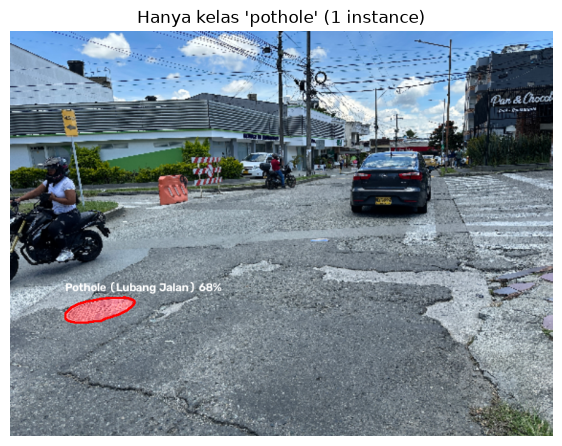

In [9]:
# Contoh A: menguji hanya SATU kelas ("pothole") pada gambar pertama yang tersedia
if TEST_IMAGES:
    sample_img = cv2.imread(TEST_IMAGES[0])
    only_pothole = {"pothole": CLASS_PROMPTS["pothole"]}

    dets = run_prompt_detection(sample_img, only_pothole)
    overlay, records = render_detections(sample_img, dets)

    plt.figure(figsize=(7, 6))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"Hanya kelas 'pothole' ({len(records)} instance)")
    plt.axis("off")
    plt.show()


WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]


[W917 19:57:48.268221687 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 3359637504 bytes (free: 1569128448, total: 12483690496).
[W917 19:57:48.390677633 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 3359637504 bytes (free: 3316056064, total: 12483690496).
[W917 19:57:48.400152045 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 3359637504 bytes (free: 3357999104, total: 12483690496).


⚠️ Multi-prompt SAM inference gagal, fallback ke prompt terpisah: CUDA out of memory. Tried to allocate 3.13 GiB. GPU 0 has a total capacity of 11.63 GiB of which 3.13 GiB is free. Process 6573 has 253.94 MiB memory in use. Including non-PyTorch memory, this process has 7.60 GiB memory in use. Of the allocated memory 5.20 GiB is allocated by PyTorch, and 2.09 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)


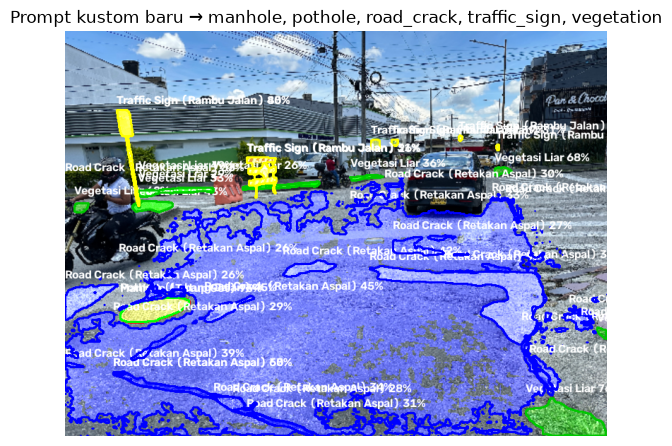

In [10]:
# Contoh B: mengganti target deteksi TOTAL BARU hanya dengan mengedit teks prompt —
# tidak ada perubahan kode, tidak ada koordinat baru yang perlu dicari.
custom_prompts = {
 
    "vegetation": {
        "text": "grass or plants growing through road cracks",
        "label": "Vegetasi Liar",
        "color": (0, 200, 0),
    },
      "pothole": {
            "text": "pothole on the road, damaged asphalt hole",
            "label": "Pothole (Lubang Jalan)",
            "color": (0, 0, 255),        # Merah (BGR)
        },
        "manhole": {
            "text": "manhole cover, sewer cover on the road",
            "label": "Manhole (Tutup Got)",
            "color": (0, 255, 0),        # Hijau (BGR)
        },
        "road_crack": {
            "text": "crack on asphalt road surface",
            "label": "Road Crack (Retakan Aspal)",
            "color": (255, 0, 0),        # Biru (BGR)
        },
        "traffic_sign": {
            "text": "traffic sign ",
            "label": "Traffic Sign (Rambu Jalan)",
            "color": (0, 255, 255),      # Kuning (BGR)
        },
    
        "water puddle": {
            "text": "water inside pothole or puddle",
            "label": "pothole",
            "color": (255, 0, 255),   # Magenta
        },
        "dry_leaves": {
            "text": "fallen leaves, usually coloured green or yellow if dry, at the ground",
            "label": "Daun Kering",
            "color": (255, 255, 0),   # Cyan
        },
}

if TEST_IMAGES:
    sample_img = cv2.imread(TEST_IMAGES[0])
    dets_custom = run_prompt_detection(sample_img, custom_prompts)
    overlay, records = render_detections(sample_img, dets_custom)

    plt.figure(figsize=(7, 6))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    title_found = ", ".join(sorted(set(r["class"] for r in records))) or "tidak ada kelas ditemukan"
    plt.title(f"Prompt kustom baru → {title_found}")
    plt.axis("off")
    plt.show()


## 7. Unified Multi-Prompt Pipeline (Seluruh Kelas Sekaligus)

Sel ini menjalankan **seluruh `CLASS_PROMPTS`** pada satu gambar contoh, menggabungkan seluruh mask ke satu overlay, dan menyusun tabel metrik ringkas — hanya untuk kelas yang benar-benar terdeteksi.


WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]


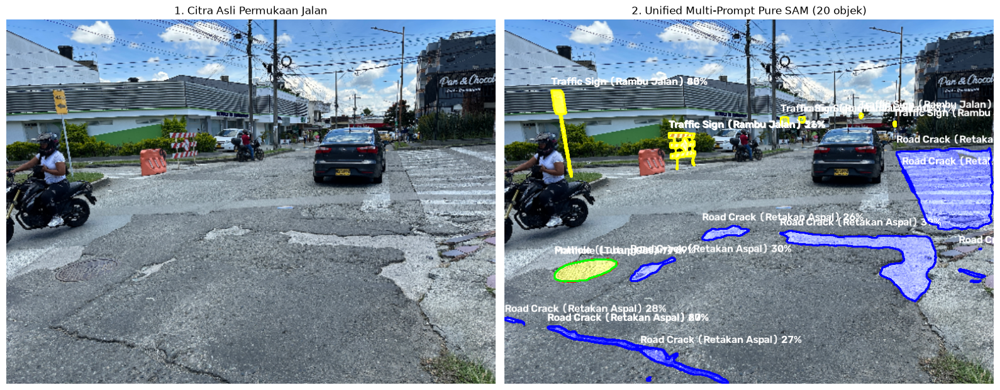

📊 Ringkasan Metrik per Kelas:
  ✅ Pothole (Lubang Jalan): 1 instance, total 0.56% dari luas gambar
  ✅ Manhole (Tutup Got): 1 instance, total 0.54% dari luas gambar
  ✅ Road Crack (Retakan Aspal): 10 instance, total 7.21% dari luas gambar
  ✅ Traffic Sign (Rambu Jalan): 8 instance, total 0.96% dari luas gambar


In [11]:
IMAGE_SAMPLE = TEST_IMAGES[0] if TEST_IMAGES else None

if IMAGE_SAMPLE:
    img_base = cv2.imread(IMAGE_SAMPLE)
    detections = run_prompt_detection(img_base, CLASS_PROMPTS)
    combined_overlay, unified_records = render_detections(img_base, detections)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(cv2.cvtColor(img_base, cv2.COLOR_BGR2RGB))
    axes[0].set_title("1. Citra Asli Permukaan Jalan", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(combined_overlay, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"2. Unified Multi-Prompt Pure SAM ({len(unified_records)} objek)", fontsize=12)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    print("📊 Ringkasan Metrik per Kelas:")
    for cls_name in CLASS_PROMPTS:
        cls_records = [r for r in unified_records if r["class"] == cls_name]
        if not cls_records:
            print(f"  ➖ {CLASS_PROMPTS[cls_name]['label']}: tidak ditemukan pada gambar ini")
            continue
        total_area_pct = sum(r["area_percent"] for r in cls_records)
        print(f"  ✅ {CLASS_PROMPTS[cls_name]['label']}: {len(cls_records)} instance, "
              f"total {total_area_pct:.2f}% dari luas gambar")
else:
    print("⚠️ Tidak ada gambar contoh di TEST_IMAGES untuk dijalankan.")


## 8. Bagian Video — Model, Kelas, dan Threshold Sepenuhnya Bisa Diatur

`VIDEO_CONFIG` adalah satu tempat untuk mengatur seluruh perilaku pipeline video:

| Key | Fungsi |
|---|---|
| `model_checkpoint` | Model SAM yang dipakai khusus untuk video. `None` = pakai model gambar yang sudah dimuat. Bisa diisi model lain (mis. `"sam2.1_t.pt"`) agar video diproses lebih cepat/hemat VRAM. |
| `classes` | Dictionary kelas (format sama seperti `CLASS_PROMPTS`) — bisa subset, superset, atau sepenuhnya berbeda dari yang dipakai di pipeline gambar. |
| `conf_threshold` | Ambang confidence khusus video. |
| `max_frames` | `None` = proses seluruh video; isi angka untuk uji cepat. |
| `skip_frames` | 1 = tiap frame diproses, 2 = tiap 2 frame (lebih cepat). |
| `resize_dim` | Resolusi pemrosesan (mengatur trade-off kecepatan vs kualitas). |

Kelas yang tidak muncul pada suatu frame otomatis dilewati di frame tersebut (bukan dipaksakan) — HUD hanya menampilkan hitungan `0`/`-` untuk kelas yang memang absen di frame itu.


In [ ]:
VIDEO_CONFIG = {
    "input_path": "testvideo1.mp4",
    "output_path": "hasil_video_pure_sam_parallel.mp4",
    "model_checkpoint": None,
    "classes": CLASS_PROMPTS,       # text-prompt interface unchanged
    "conf_threshold": 0.25,

    "max_frames": 300,              # None = entire video
    "skip_frames": 1,
    "resize_dim": (640, 480),
    "sam_imgsz": 560,  # adjust after the image-size sweep if needed

    # Full SAM semantic detection every N processed frames.
    "detect_interval": 5,

    # Non-SAM frame handling.
    # hold  = cheapest; reuse last masks
    # phase = cheap global translation
    # flow  = dense Farneback (CPU-heavy, opt-in only)
    "propagation": "hold",
    "flow_scale": 0.5,
    "redetect_on_empty": False,  # wait for the next scheduled keyframe

    # Parallel CPU pipeline. GPU inference remains single-owner to avoid
    # multiple model contexts fighting over the same 3080 Ti.
    "prefetch_frames": 12,
    "postprocess_workers": 6,
    "postprocess_queue": 12,
    "max_inflight_results": 12,

    # Writer runs in its own thread so VideoWriter does not block GPU inference.
    "async_writer": True,
}
print("PARALLEL VIDEO CONFIG")
for k, v in VIDEO_CONFIG.items():
    print(f"  {k}: {v}")


In [13]:
# Benchmark the construction-time SAM image size before processing the video.
# This measures a short slice of VIDEO_CONFIG["input_path"] and reports both timing
# and detected-instance totals per class. Use the counts, not timing alone, when
# choosing the size.
# Ultralytics may round the requested imgsz to the model stride (for example,
# 768 may become 770), so treat the printed setting as the requested size.
BENCH_SAM_IMGSZ = (448, 560, 770)
BENCH_KEYFRAMES = min(12, int(VIDEO_CONFIG.get("max_frames") or 12))
BENCH_REPEATS = 2

bench_checkpoint = VIDEO_CONFIG.get("model_checkpoint") or SAM_CHECKPOINT
if get_sam_mode(bench_checkpoint) != "concept":
    print("SAM imgsz sweep skipped: text-prompt benchmarking requires SAM 3/3.1 concept mode.")
else:
    bench_conf = float(VIDEO_CONFIG.get("conf_threshold", CONFIDENCE_THRESHOLD))
    bench_classes = VIDEO_CONFIG["classes"]
    bench_names = list(bench_classes.keys())
    bench_texts = [bench_classes[name]["text"] for name in bench_names]

    cap_bench = cv2.VideoCapture(str(VIDEO_CONFIG["input_path"]))
    bench_frames = []
    if cap_bench.isOpened():
        while len(bench_frames) < BENCH_KEYFRAMES:
            ok, frame = cap_bench.read()
            if not ok:
                break
            if VIDEO_CONFIG.get("resize_dim"):
                frame = cv2.resize(
                    frame, VIDEO_CONFIG["resize_dim"], interpolation=cv2.INTER_AREA
                )
            bench_frames.append(frame)
    cap_bench.release()

    if not bench_frames:
        print(
            "Benchmark skipped: video not found or no frames readable: "
            f"{VIDEO_CONFIG['input_path']}"
        )
    else:
        print("=" * 72)
        print(
            f"SAM IMGSZ SWEEP — {len(bench_frames)} keyframe(s) from "
            f"{VIDEO_CONFIG['input_path']}"
        )
        print(f"Classes: {bench_names}")
        for requested_imgsz in BENCH_SAM_IMGSZ:
            predictor_bench = SAM3SemanticPredictor(overrides=dict(
                conf=bench_conf,
                task="segment",
                mode="predict",
                model=bench_checkpoint,
                device=DEVICE,
                imgsz=requested_imgsz,
                half=torch.cuda.is_available(),
                verbose=False,
                save=False,
            ))

            # One warm-up pass at this size. The timed section below measures
            # set_image + batched text inference per keyframe.
            predictor_bench.set_image(bench_frames[0])
            predictor_bench(text=bench_texts)
            if torch.cuda.is_available():
                torch.cuda.synchronize()

            counts = {name: 0 for name in bench_names}
            class_ids_ok = True
            t0 = time.perf_counter()

            for _ in range(BENCH_REPEATS):
                for frame_bench in bench_frames:
                    predictor_bench.set_image(frame_bench)
                    raw_bench = predictor_bench(text=bench_texts)
                    result_bench = (
                        raw_bench[0]
                        if isinstance(raw_bench, (list, tuple))
                        else raw_bench
                    )
                    _, _, ids_bench = _extract_instances(result_bench)

                    if ids_bench is None or (
                        ids_bench.size and (
                            int(ids_bench.min()) < 0
                            or int(ids_bench.max()) >= len(bench_names)
                        )
                    ):
                        class_ids_ok = False
                    elif ids_bench.size:
                        for idx_bench in ids_bench:
                            counts[bench_names[int(idx_bench)]] += 1

            if torch.cuda.is_available():
                torch.cuda.synchronize()

            elapsed_ms = (time.perf_counter() - t0) * 1000.0
            per_keyframe_ms = elapsed_ms / (len(bench_frames) * BENCH_REPEATS)

            count_text = ", ".join(
                f"{name}={counts[name] / BENCH_REPEATS:.1f}"
                for name in bench_names
            )
            suffix = (
                ""
                if class_ids_ok
                else " | WARNING: boxes.cls unavailable/invalid; "
                     "counts are not trustworthy"
            )
            print(
                f"  imgsz={requested_imgsz:>3d}: "
                f"{per_keyframe_ms:7.1f} ms/keyframe | "
                f"avg instances/keyframe: {count_text}{suffix}"
            )

            del predictor_bench
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        print("=" * 72)


SAM IMGSZ SWEEP — 12 keyframe(s) from testvideo1.mp4
Classes: ['pothole', 'manhole', 'road_crack', 'traffic_sign']
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.126 🚀 Python-3.14.4 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3080 Ti, 11905MiB)
  imgsz=448:    75.2 ms/keyframe | avg instances/keyframe: pothole=225.0, manhole=0.0, road_crack=0.0, traffic_sign=5.0
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.126 🚀 Python-3.14.4 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3080 Ti, 11905MiB)
  imgsz=560:    92.1 ms/keyframe | avg instances/keyframe: pothole=346.0, manhole=0.0, road_crack=0.0, traffic_sign=0.0
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.126 🚀 Python-3.14.4 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3080 Ti, 11905MiB)
  imgsz=770:   190.1 ms/keyframe | avg instances/keyframe: pothole=45

## 9. Parallel Video Processing Architecture

The video engine is now explicitly split into concurrent stages:

```text
Video decode/resize thread(s)
        ↓ bounded frame queue
Single GPU SAM worker  ← one owner of the predictor
        ↓ bounded result queue
CPU post-processing worker pool
        ↓ ordered result queue
Dedicated video writer thread
```

Important: SAM 3/3.1 image concept prediction currently does **not** support batching multiple images in one predictor call. Therefore this version does not fake frame batching or launch multiple model copies. Instead it keeps the GPU continuously supplied while CPU decode, rendering, metric calculation, and video writing happen concurrently.

The major GPU-side optimization is also now enabled: **all text prompts are sent to SAM in one call per keyframe**, after the image is set once. Ultralytics documents this multi-prompt interface and reusing image features for multiple queries.

`CLASS_PROMPTS` remains unchanged.


In [14]:
def ensure_backend_for_video(video_config):
    """Ensure the global SAM backend matches VIDEO_CONFIG."""
    global SAM_CHECKPOINT, SAM_MODE, sam_predictor, sam_model_visual

    requested = video_config.get("model_checkpoint")
    checkpoint = requested if requested else SAM_CHECKPOINT
    mode = get_sam_mode(checkpoint)
    target_imgsz = int(video_config.get("sam_imgsz", 560))

    if mode == "concept" and not _SAM3_TEXT_PROMPT_READY:
        raise RuntimeError(
            "SAM 3/3.1 text-prompt mode was requested, but "
            "SAM3SemanticPredictor is unavailable. Upgrade Ultralytics and restart."
        )

    backend_missing = (
        (mode == "concept" and sam_predictor is None)
        or (mode == "visual" and sam_model_visual is None)
    )
    needs_rebuild = (
        checkpoint != SAM_CHECKPOINT
        or backend_missing
        or (mode == "concept" and SAM_ACTIVE_IMGSZ != target_imgsz)
    )

    if needs_rebuild:
        print(
            f"Switching video backend -> {checkpoint} "
            f"(mode={mode}, imgsz={target_imgsz})"
        )
        conf = float(video_config.get("conf_threshold", CONFIDENCE_THRESHOLD))
        build_sam_backend(
            checkpoint, mode, conf=conf, imgsz=target_imgsz, device=DEVICE
        )
        SAM_CHECKPOINT = checkpoint
        SAM_MODE = mode

    return SAM_MODE


print("Video backend guard ready: ensure_backend_for_video()")


Video backend guard ready: ensure_backend_for_video()


In [ ]:
# Guard against the video size optimization silently becoming a no-op.
ensure_backend_for_video(VIDEO_CONFIG)
if SAM_MODE == "concept":
    assert SAM_ACTIVE_IMGSZ == int(VIDEO_CONFIG["sam_imgsz"]), (
        f"SAM_ACTIVE_IMGSZ={SAM_ACTIVE_IMGSZ}, "
        f"VIDEO_CONFIG['sam_imgsz']={VIDEO_CONFIG['sam_imgsz']}"
    )
    print(f"Verified: concept backend is built at imgsz={SAM_ACTIVE_IMGSZ}.")
else:
    print("Visual SAM backend active; construction-time imgsz is not used by this path.")


In [ ]:
def _translate_detections_phase(prev_frame, curr_frame, detections):
    """Translate prior masks using global phase correlation (cheap CPU propagation)."""
    if not detections:
        return {}

    h, w = curr_frame.shape[:2]
    prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
    curr_gray = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2GRAY)

    shift, response = cv2.phaseCorrelate(
        np.float32(prev_gray), np.float32(curr_gray)
    )
    dx, dy = shift
    if (
        not np.isfinite(dx) or not np.isfinite(dy)
        or not np.isfinite(response)
        or abs(dx) >= w or abs(dy) >= h
    ):
        return detections

    matrix = np.array(
        [[1.0, 0.0, float(round(dx))],
         [0.0, 1.0, float(round(dy))]],
        dtype=np.float32,
    )

    translated = {}
    for cls_name, det in detections.items():
        masks_out = []
        for mask in det.get("masks", []):
            mask_bin = (mask > 0.5).astype(np.float32)
            if mask_bin.shape != (h, w):
                mask_bin = cv2.resize(
                    mask_bin, (w, h), interpolation=cv2.INTER_NEAREST
                )
            warped = cv2.warpAffine(
                mask_bin, matrix, (w, h),
                flags=cv2.INTER_NEAREST,
                borderMode=cv2.BORDER_CONSTANT,
                borderValue=0,
            )
            masks_out.append(warped)

        if masks_out:
            translated[cls_name] = {
                "masks": np.stack(masks_out, axis=0),
                "confidences": np.asarray(
                    det.get("confidences", []), dtype=np.float32
                ).copy(),
                "label": det["label"],
                "color": det["color"],
            }

    return translated


def _propagate_detections(prev_frame, curr_frame, detections, flow_scale=0.5):
    """Propagate SAM masks from the previous processed frame using dense optical flow.

    SAM is still responsible for semantic discovery. Optical flow only moves the
    already-detected masks between nearby frames, which is much cheaper than
    running the text-prompt model on every frame.
    """
    if not detections:
        return {}

    h, w = curr_frame.shape[:2]
    scale = float(np.clip(flow_scale, 0.25, 1.0))
    fw = max(32, int(w * scale))
    fh = max(32, int(h * scale))

    prev_gray = cv2.cvtColor(
        cv2.resize(prev_frame, (fw, fh), interpolation=cv2.INTER_AREA),
        cv2.COLOR_BGR2GRAY,
    )
    curr_gray = cv2.cvtColor(
        cv2.resize(curr_frame, (fw, fh), interpolation=cv2.INTER_AREA),
        cv2.COLOR_BGR2GRAY,
    )

    flow_small = cv2.calcOpticalFlowFarneback(
        prev_gray,
        curr_gray,
        None,
        pyr_scale=0.5,
        levels=2,
        winsize=15,
        iterations=2,
        poly_n=5,
        poly_sigma=1.2,
        flags=0,
    )

    # Convert flow back to full-resolution pixel units.
    flow_x = cv2.resize(flow_small[..., 0], (w, h), interpolation=cv2.INTER_LINEAR)
    flow_y = cv2.resize(flow_small[..., 1], (w, h), interpolation=cv2.INTER_LINEAR)
    flow_x *= (w / fw)
    flow_y *= (h / fh)

    grid_x, grid_y = np.meshgrid(
        np.arange(w, dtype=np.float32),
        np.arange(h, dtype=np.float32),
    )

    # Backward remap: for each current pixel, sample its corresponding
    # previous-frame pixel.
    map_x = grid_x - flow_x
    map_y = grid_y - flow_y

    propagated = {}
    for cls_name, det in detections.items():
        masks_out = []
        confs_out = []

        for i, mask in enumerate(det["masks"]):
            mask_bin = (mask > 0.5).astype(np.uint8) * 255
            if mask_bin.shape != (h, w):
                mask_bin = cv2.resize(
                    mask_bin, (w, h), interpolation=cv2.INTER_NEAREST
                )

            warped = cv2.remap(
                mask_bin,
                map_x,
                map_y,
                interpolation=cv2.INTER_NEAREST,
                borderMode=cv2.BORDER_CONSTANT,
                borderValue=0,
            )

            # Remove tiny flow artifacts.
            warped = (warped > 127).astype(np.float32)
            if warped.sum() < 16:
                continue

            masks_out.append(warped)
            if i < len(det["confidences"]):
                confs_out.append(float(det["confidences"][i]))

        if masks_out:
            propagated[cls_name] = {
                "masks": np.stack(masks_out, axis=0),
                "confidences": np.asarray(confs_out, dtype=np.float32),
                "label": det["label"],
                "color": det["color"],
            }

    return propagated


def _count_detection_pixels(records, class_prompts):
    """Consume metrics already computed by render_detections; do not touch masks again."""
    counts = {cls: 0 for cls in class_prompts}
    total_damage_px = 0
    for record in records:
        cls_name = record["class"]
        counts[cls_name] = counts.get(cls_name, 0) + 1
        total_damage_px += int(record["pixel_area"])
    return counts, total_damage_px


def _postprocess_video_frame(frame_idx, frame_proc, detections, class_prompts,
                             out_w, out_h, fps_in, throughput, source,
                             sam_calls, gallery_stride):
    """CPU-side work executed in a worker thread."""
    annotated, records = render_detections(frame_proc, detections)
    counts, total_damage_px = _count_detection_pixels(
        records, class_prompts
    )

    cv2.putText(
        annotated,
        f"{throughput:.1f} FPS | {source} | SAM calls: {sam_calls}",
        (15, 28),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (255, 255, 255),
        2,
    )

    log_item = {
        "frame": frame_idx,
        "time_sec": frame_idx / fps_in,
        "source": source,
        "counts": counts,
        "damage_pixels": total_damage_px,
        "damage_pct": (total_damage_px / (out_w * out_h)) * 100.0,
        "records": records,
    }

    sample = (frame_idx, annotated.copy()) if frame_idx % gallery_stride == 0 else None
    return frame_idx, annotated, log_item, sample


def process_video_pure_sam(video_config):
    """3080 Ti-oriented asynchronous video pipeline.

    Stage A: a producer thread continuously decodes/resizes frames into a bounded queue.
    Stage B: the main thread owns the single SAM predictor and performs semantic GPU work.
    Stage C: multiple CPU workers render masks and calculate metrics concurrently with SAM.
    Stage D: a dedicated writer thread writes completed frames in original order.

    SAM 3/3.1 does not currently support multi-image batching, so the GPU stage remains
    one frame at a time. The important parallelism is between GPU inference and CPU/I/O.
    """
    mode = ensure_backend_for_video(video_config)

    video_path = video_config["input_path"]
    output_path = video_config["output_path"]
    class_prompts = video_config["classes"]
    conf_th = video_config.get("conf_threshold", CONFIDENCE_THRESHOLD)
    max_frames = video_config.get("max_frames")
    skip_frames = max(1, int(video_config.get("skip_frames", 1)))
    resize_dim = video_config.get("resize_dim")
    sam_imgsz = video_config.get("sam_imgsz", 560)
    detect_interval = max(1, int(video_config.get("detect_interval", 5)))
    propagation = str(video_config.get("propagation", "hold")).lower()
    redetect_on_empty = bool(video_config.get("redetect_on_empty", False))

    prefetch_size = max(2, int(video_config.get("prefetch_frames", 12)))
    post_workers = max(1, int(video_config.get("postprocess_workers", 6)))
    result_queue_size = max(2, int(video_config.get("postprocess_queue", 12)))
    max_inflight = max(2, int(video_config.get("max_inflight_results", result_queue_size)))

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise IOError(f"Video tidak ditemukan: {video_path}")

    orig_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    orig_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps_in = cap.get(cv2.CAP_PROP_FPS) or 30.0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    out_w, out_h = resize_dim if resize_dim else (orig_w, orig_h)
    output_fps = fps_in / skip_frames

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_path), fourcc, output_fps, (out_w, out_h))
    if not writer.isOpened():
        cap.release()
        raise IOError(f"Gagal membuka VideoWriter: {output_path}")

    print("=" * 72)
    print("PARALLEL SAM VIDEO PIPELINE — RTX 3080 Ti")
    print(f"Model              : {SAM_CHECKPOINT} (mode={mode})")
    print(f"Classes            : {list(class_prompts.keys())}")
    print(f"Resolution          : {orig_w}x{orig_h} -> {out_w}x{out_h}")
    print(f"SAM image size      : {sam_imgsz}")
    print(f"Input FPS           : {fps_in:.1f}")
    print(f"SAM interval        : every {detect_interval} processed frame(s)")
    print(f"Propagation         : {propagation}")
    print(f"Frame prefetch      : {prefetch_size}")
    print(f"CPU post workers    : {post_workers}")
    print(f"Result queue        : {result_queue_size}")
    print("GPU strategy        : one predictor owner + ALL text prompts in one call")
    print("=" * 72)

    frame_queue = queue.Queue(maxsize=prefetch_size)
    result_queue = queue.Queue(maxsize=result_queue_size)
    producer_done = threading.Event()
    writer_error = []

    gallery_target = max_frames or total_frames or 1
    gallery_stride = max(1, gallery_target // 5)

    # Producer: keep decoding/resizing ahead of the GPU.
    def producer():
        frame_idx = 0
        processed = 0
        try:
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break
                if frame_idx % skip_frames != 0:
                    frame_idx += 1
                    continue
                if max_frames and processed >= max_frames:
                    break
                frame_proc = (
                    cv2.resize(frame, resize_dim, interpolation=cv2.INTER_AREA)
                    if resize_dim else frame
                )
                frame_queue.put((frame_idx, frame_proc), block=True)
                processed += 1
                frame_idx += 1
        finally:
            producer_done.set()
            frame_queue.put(None, block=True)

    # Writer: maintain frame order even if CPU post-processing workers finish out of order.
    def writer_loop():
        next_idx = None
        pending = {}
        try:
            while True:
                item = result_queue.get()
                if item is None:
                    # Drain pending items in order before exiting.
                    if pending:
                        for idx in sorted(pending):
                            writer.write(pending[idx][1])
                    break
                idx, annotated, log_item, sample = item
                pending[idx] = item
                if next_idx is None:
                    next_idx = min(pending)
                while next_idx in pending:
                    current = pending.pop(next_idx)
                    writer.write(current[1])
                    next_idx += skip_frames
        except Exception as e:
            writer_error.append(e)

    producer_thread = threading.Thread(target=producer, name="video-producer", daemon=True)
    writer_thread = threading.Thread(target=writer_loop, name="video-writer", daemon=True)
    producer_thread.start()
    writer_thread.start()

    temporal_log = []
    sample_frames = []
    previous_frame = None
    previous_detections = {}
    sam_calls = 0
    propagated_frames = 0
    processed = 0
    start_time = time.perf_counter()
    submitted = 0
    completed = 0

    # ThreadPoolExecutor uses worker threads for OpenCV/Numpy CPU work. Most of
    # these operations release the GIL, so multiple cores can be used concurrently.
    executor = ThreadPoolExecutor(max_workers=post_workers, thread_name_prefix="post")
    futures = []

    try:
        while True:
            item = frame_queue.get()
            if item is None:
                break
            frame_idx, frame_proc = item

            need_detection = (
                processed == 0
                or (processed % detect_interval == 0)
                or (redetect_on_empty and not previous_detections)
            )

            if need_detection:
                # Single GPU owner: do not invoke the predictor from CPU worker threads.
                detections = run_prompt_detection(
                    frame_proc,
                    class_prompts,
                    conf_threshold=conf_th,
                )
                sam_calls += 1
                source = "SAM"
            else:
                if propagation == "phase" and previous_frame is not None:
                    detections = _translate_detections_phase(
                        previous_frame, frame_proc, previous_detections
                    )
                    source = "PHASE"
                elif propagation == "flow" and previous_frame is not None:
                    detections = _propagate_detections(
                        previous_frame, frame_proc, previous_detections,
                        flow_scale=video_config.get("flow_scale", 0.5),
                    )
                    source = "FLOW"
                else:
                    # Read-only reuse: no deep copy needed because rendering does not mutate detections.
                    detections = previous_detections
                    source = "HOLD"
                propagated_frames += 1

            elapsed = max(time.perf_counter() - start_time, 1e-6)
            throughput = (processed + 1) / elapsed

            future = executor.submit(
                _postprocess_video_frame,
                frame_idx, frame_proc, detections, class_prompts,
                out_w, out_h, fps_in, throughput, source,
                sam_calls, gallery_stride,
            )
            futures.append(future)
            submitted += 1

            # Bound the amount of completed-but-not-written work so RAM cannot grow forever.
            if len(futures) >= max_inflight:
                done = futures.pop(0).result()
                result_queue.put(done, block=True)
                temporal_log.append(done[2])
                if done[3] is not None:
                    sample_frames.append(done[3])
                completed += 1

            previous_frame = frame_proc
            previous_detections = detections
            processed += 1

            if processed % 15 == 0:
                elapsed = max(time.perf_counter() - start_time, 1e-6)
                print(
                    f"  {processed}/{max_frames or total_frames} | "
                    f"GPU-stage throughput: {processed / elapsed:.1f} FPS | "
                    f"SAM={sam_calls} | {source} | "
                    f"inflight={len(futures)}"
                )

        # Flush all outstanding post-processing work.
        for future in futures:
            done = future.result()
            result_queue.put(done, block=True)
            temporal_log.append(done[2])
            if done[3] is not None:
                sample_frames.append(done[3])
            completed += 1
    finally:
        executor.shutdown(wait=True)
        result_queue.put(None, block=True)
        writer_thread.join()
        producer_thread.join()
        cap.release()
        writer.release()

    if writer_error:
        raise writer_error[0]

    total_time = max(time.perf_counter() - start_time, 1e-6)
    avg_fps = processed / total_time if processed else 0.0
    temporal_log.sort(key=lambda x: x["frame"])
    sample_frames.sort(key=lambda x: x[0])

    print("=" * 72)
    print("VIDEO COMPLETE")
    print(f"Frames processed     : {processed}")
    print(f"Total time           : {total_time:.2f} s")
    print(f"Average throughput   : {avg_fps:.2f} FPS")
    print(f"SAM calls            : {sam_calls}")
    print(f"Non-SAM frames       : {propagated_frames}")
    print(f"CPU post workers     : {post_workers}")
    print(f"Output               : {output_path}")
    print("=" * 72)

    return temporal_log, sample_frames


### 9.1 RTX 3080 Ti tuning

Recommended baseline:

```python
VIDEO_CONFIG["detect_interval"] = 5
VIDEO_CONFIG["propagation"] = "hold"
VIDEO_CONFIG["prefetch_frames"] = 12
VIDEO_CONFIG["postprocess_workers"] = 6
VIDEO_CONFIG["postprocess_queue"] = 12
```

The important change is that the GPU predictor is no longer surrounded by synchronous CPU rendering and video writing. CPU workers render frames while the GPU starts the next inference.

For SAM 3/3.1, all active text prompts are also sent together in one predictor call. Ultralytics currently documents multiple text prompts in a single call, while its semantic predictor does not support batching multiple images. Therefore **prompt batching is enabled; frame batching is not faked**.

If GPU utilization is still only ~30–40%, increase `resize_dim` or reduce `detect_interval` to make the GPU stage heavier. If GPU utilization rises while FPS improves, the previous pipeline was under-feeding the GPU.


## 9.2 Pipeline sanity check

This cell verifies the active architecture before processing the full video. It does not run inference.


In [17]:
print('Parallel pipeline settings:')
for k in ['prefetch_frames','postprocess_workers','postprocess_queue','max_inflight_results','detect_interval','propagation','resize_dim']:
    print(f'  {k}: {VIDEO_CONFIG.get(k)}')
if SAM_MODE == 'concept':
    print('GPU prompt strategy: ALL active text prompts are sent in one SAM call per keyframe.')
    print('Frame batching: disabled because SAM3SemanticPredictor currently supports one image per set_image call.')
else:
    print('Legacy visual mode: multi-prompt semantic batching is unavailable.')


Parallel pipeline settings:
  prefetch_frames: 12
  postprocess_workers: 6
  postprocess_queue: 12
  max_inflight_results: 12
  detect_interval: 5
  propagation: hold
  resize_dim: (640, 480)
GPU prompt strategy: ALL active text prompts are sent in one SAM call per keyframe.
Frame batching: disabled because SAM3SemanticPredictor currently supports one image per set_image call.


## 10. Eksekusi Video Sesuai `VIDEO_CONFIG`


In [18]:
# Parallel pipeline presets
# Start here.
VIDEO_CONFIG["propagation"] = "hold"
VIDEO_CONFIG["detect_interval"] = 5
VIDEO_CONFIG["prefetch_frames"] = 12
VIDEO_CONFIG["postprocess_workers"] = 6
VIDEO_CONFIG["postprocess_queue"] = 12
VIDEO_CONFIG["max_inflight_results"] = 12

# If the CPU has many cores, try 8 or 10 post workers.
# VIDEO_CONFIG["postprocess_workers"] = 8

# If GPU utilization is still low, test more frequent SAM correction.
# VIDEO_CONFIG["detect_interval"] = 3

# Do not enable dense optical flow while benchmarking GPU throughput.
# VIDEO_CONFIG["propagation"] = "flow"


PARALLEL SAM VIDEO PIPELINE — RTX 3080 Ti
Model              : sam3_1.pt (mode=concept)
Classes            : ['pothole', 'manhole', 'road_crack', 'traffic_sign']
Resolution          : 1920x1080 -> 640x480
SAM image size      : 1024
Input FPS           : 30.0
SAM interval        : every 5 processed frame(s)
Propagation         : hold
Frame prefetch      : 12
CPU post workers    : 6
Result queue        : 12
GPU strategy        : one predictor owner + ALL text prompts in one call
WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]
  15/300 | GPU-stage throughput: 12.7 FPS | SAM=3 | HOLD | inflight=11
WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14

/tmp/ipykernel_1067560/3338177382.py:14: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/bondry/miky/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


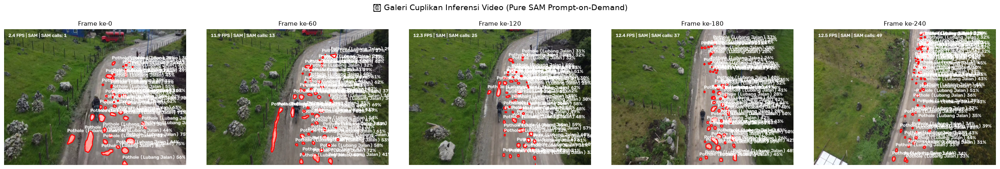

In [19]:
if Path(VIDEO_CONFIG["input_path"]).exists():
    damage_log, sample_frames = process_video_pure_sam(VIDEO_CONFIG)

    if sample_frames:
        num_samples = len(sample_frames)
        fig, axes = plt.subplots(1, num_samples, figsize=(5 * num_samples, 4))
        if num_samples == 1:
            axes = [axes]
        for ax, (f_idx, f_img) in zip(axes, sample_frames):
            ax.imshow(cv2.cvtColor(f_img, cv2.COLOR_BGR2RGB))
            ax.set_title(f"Frame ke-{f_idx}", fontsize=11)
            ax.axis("off")
        plt.suptitle("📸 Galeri Cuplikan Inferensi Video (Pure SAM Prompt-on-Demand)", fontsize=14, y=1.03)
        plt.tight_layout()
        plt.show()
else:
    damage_log, sample_frames = [], []
    print(f"⚠️ File video '{VIDEO_CONFIG['input_path']}' tidak ditemukan di direktori kerja.")
    print("   Letakkan file video Anda lalu jalankan ulang sel ini.")


## 11. Analisis Metrik Temporal Kerusakan Jalan

Grafik ini sepenuhnya mengikuti kelas yang didefinisikan di `VIDEO_CONFIG["classes"]` — tidak ada kelas yang di-hardcode di sini, sehingga tetap relevan berapa pun jumlah/nama kelas yang Anda pakai.


/tmp/ipykernel_1067560/3760520020.py:26: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1067560/3760520020.py:27: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("grafik_analisis_temporal_jalan.png", dpi=300)
/home/bondry/miky/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


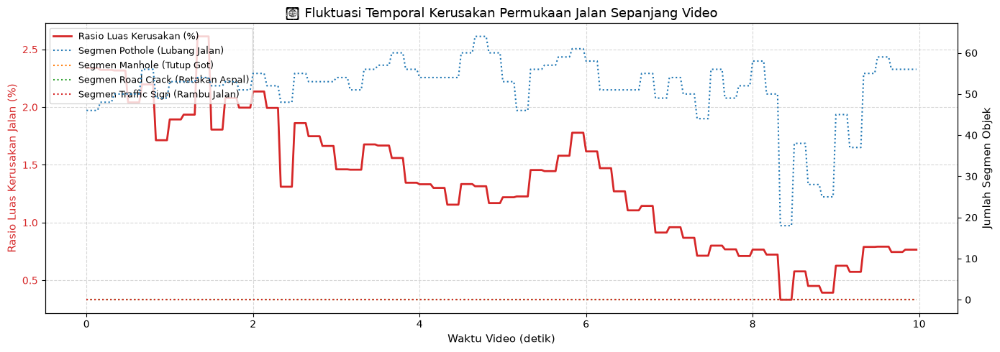

📊 KESIMPULAN ANALISIS TEMPORAL:
  • Titik kerusakan tertinggi : detik ke-1.33 (2.61% area)
  • Rata-rata rasio kerusakan : 1.36%
  • Pothole (Lubang Jalan): 15440 total kemunculan segmen, muncul di 300/300 frame
  • Manhole (Tutup Got): 0 total kemunculan segmen, muncul di 0/300 frame
  • Road Crack (Retakan Aspal): 0 total kemunculan segmen, muncul di 0/300 frame
  • Traffic Sign (Rambu Jalan): 0 total kemunculan segmen, muncul di 0/300 frame


In [20]:
if damage_log:
    times = [d["time_sec"] for d in damage_log]
    dmg_pcts = [d["damage_pct"] for d in damage_log]
    class_names = list(VIDEO_CONFIG["classes"].keys())

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.set_xlabel("Waktu Video (detik)", fontsize=11)
    ax1.set_ylabel("Rasio Luas Kerusakan Jalan (%)", color="tab:red", fontsize=11)
    ax1.plot(times, dmg_pcts, color="tab:red", linewidth=2, label="Rasio Luas Kerusakan (%)")
    ax1.tick_params(axis="y", labelcolor="tab:red")
    ax1.grid(True, linestyle="--", alpha=0.5)

    ax2 = ax1.twinx()
    ax2.set_ylabel("Jumlah Segmen Objek", fontsize=11)
    palette = plt.cm.tab10.colors
    for i, cls_name in enumerate(class_names):
        counts = [d["counts"].get(cls_name, 0) for d in damage_log]
        label = VIDEO_CONFIG["classes"][cls_name].get("label", cls_name)
        ax2.plot(times, counts, linestyle=":", color=palette[i % len(palette)], label=f"Segmen {label}")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

    plt.title("📈 Fluktuasi Temporal Kerusakan Permukaan Jalan Sepanjang Video", fontsize=13)
    plt.tight_layout()
    plt.savefig("grafik_analisis_temporal_jalan.png", dpi=300)
    plt.show()

    max_idx = int(np.argmax(dmg_pcts))
    print("=" * 60)
    print("📊 KESIMPULAN ANALISIS TEMPORAL:")
    print(f"  • Titik kerusakan tertinggi : detik ke-{times[max_idx]:.2f} ({dmg_pcts[max_idx]:.2f}% area)")
    print(f"  • Rata-rata rasio kerusakan : {np.mean(dmg_pcts):.2f}%")
    for cls_name in class_names:
        label = VIDEO_CONFIG["classes"][cls_name].get("label", cls_name)
        total_cnt = sum(d["counts"].get(cls_name, 0) for d in damage_log)
        frames_present = sum(1 for d in damage_log if d["counts"].get(cls_name, 0) > 0)
        print(f"  • {label}: {total_cnt} total kemunculan segmen, muncul di {frames_present}/{len(damage_log)} frame")
    print("=" * 60)
else:
    print("Tidak ada data temporal (video belum diproses atau tidak ada frame yang terbaca).")


## 12. Catatan: Mode Legacy (Visual Box/Point) & Troubleshooting

Bagian ini hanya relevan jika notebook jatuh ke **mode `visual`** (SAM 2.1) karena `sam3_1.pt`/`sam3.pt` belum tersedia.

### Mengaktifkan mode prompt teks (direkomendasikan)
1. Minta akses & unduh bobot di halaman model resmi Hugging Face (`facebook/sam3.1` atau `facebook/sam3`).
2. Taruh file `sam3_1.pt` (atau `sam3.pt`) di direktori kerja notebook ini.
3. Pastikan `ultralytics >= 8.3.237`: `pip install -U ultralytics`.
4. Jalankan ulang notebook dari Bagian 2.

### Menggunakan mode legacy (box/point manual) jika belum punya bobot SAM 3/3.1
Format konfigurasi legacy sama seperti `CLASS_PROMPTS`, tetapi menggunakan `boxes`/`points` alih-alih `text` — dan **harus disesuaikan ulang setiap ganti gambar**, karena inilah yang coba dihindari oleh mode `concept`:

```python
LEGACY_VISUAL_PROMPTS = {
    "pothole": {
        "label": "Pothole (Lubang Jalan)",
        "color": (0, 0, 255),
        "boxes": [[424, 323, 720, 454]],   # Koordinat spesifik untuk SATU gambar tertentu
        "points": [[560, 385]],
        "point_labels": [1],
    },
}

# Gunakan show_coordinate_helper("nama_gambar.png") untuk membantu menentukan koordinat.
# detections = run_prompt_detection(img_bgr, LEGACY_VISUAL_PROMPTS)  # otomatis pakai backend visual
```

### Tips VRAM
- `sam2.1_t.pt` (Tiny) — paling ringan, cocok GPU 4 GB seperti RTX 3050.
- `sam3.pt` / `sam3_1.pt` — jauh lebih besar (≈3.3–3.5 GB model, butuh VRAM signifikan lebih banyak saat inferensi). Jika VRAM terbatas, turunkan `imgsz` pada `build_sam_backend`, kecilkan `resize_dim` pada `VIDEO_CONFIG`, atau gunakan `sam2.1_t.pt` khusus untuk video (`VIDEO_CONFIG["model_checkpoint"] = "sam2.1_t.pt"`) sambil tetap memakai SAM 3.1 untuk gambar.


WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]


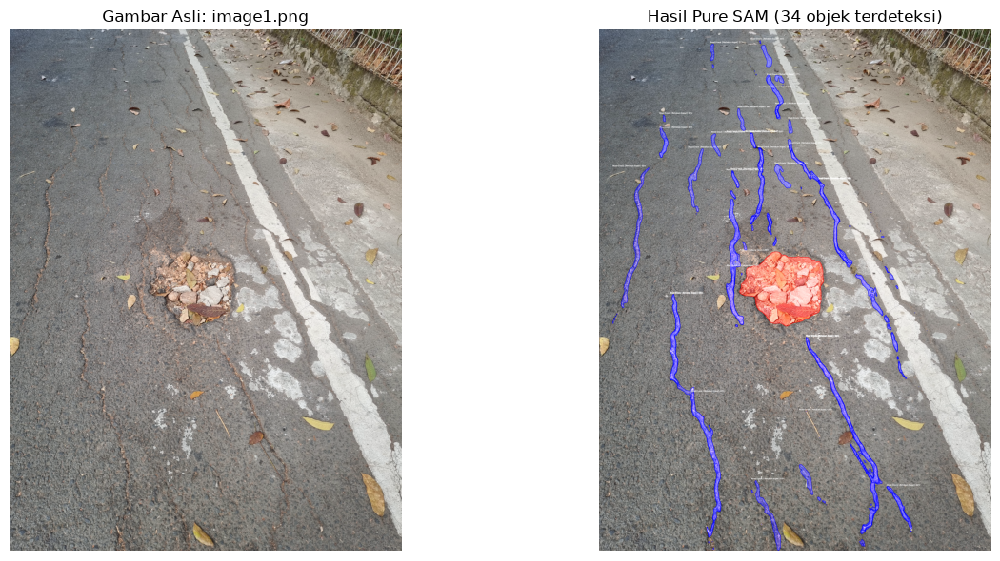

 Kelas terdeteksi pada 'image1.png': ['pothole', 'road_crack']
➖ Tidak ditemukan (dilewati, bukan dipaksakan): ['manhole', 'traffic_sign']
    • Pothole (Lubang Jalan) #1: 257,589 px (2.15% dari gambar), confidence=0.88
    • Road Crack (Retakan Aspal) #1: 31,107 px (0.26% dari gambar), confidence=0.62
    • Road Crack (Retakan Aspal) #2: 12,584 px (0.10% dari gambar), confidence=0.61
    • Road Crack (Retakan Aspal) #3: 52,031 px (0.43% dari gambar), confidence=0.56
    • Road Crack (Retakan Aspal) #4: 20,874 px (0.17% dari gambar), confidence=0.56
    • Road Crack (Retakan Aspal) #5: 64,034 px (0.53% dari gambar), confidence=0.50
    • Road Crack (Retakan Aspal) #6: 36,109 px (0.30% dari gambar), confidence=0.49
    • Road Crack (Retakan Aspal) #7: 16,948 px (0.14% dari gambar), confidence=0.43
    • Road Crack (Retakan Aspal) #8: 37,552 px (0.31% dari gambar), confidence=0.40
    • Road Crack (Retakan Aspal) #9: 5,660 px (0.05% dari gambar), confidence=0.39
    • Road Crack (Retakan

In [21]:
TEST_IMAGES = ["image1.png"]
TEST_IMAGES = [p for p in TEST_IMAGES if Path(p).exists()]

if not TEST_IMAGES:
    print(" Tidak ada file pada TEST_IMAGES yang ditemukan di direktori kerja.")
    print("   Tambahkan nama file gambar Anda ke list TEST_IMAGES di atas.")

for img_path in TEST_IMAGES:
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f" Gagal membaca: {img_path}")
        continue

    detections = run_prompt_detection(img_bgr, CLASS_PROMPTS)
    overlay, records = render_detections(img_bgr, detections)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Gambar Asli: {img_path}", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Hasil Pure SAM ({len(records)} objek terdeteksi)", fontsize=12)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    found_classes = sorted(set(r["class"] for r in records))
    missing_classes = [c for c in CLASS_PROMPTS if c not in found_classes]

    print(f" Kelas terdeteksi pada '{img_path}': {found_classes or '(tidak ada)'}")
    if missing_classes:
        print(f"➖ Tidak ditemukan (dilewati, bukan dipaksakan): {missing_classes}")
    for r in records:
        conf_txt = f", confidence={r['confidence']:.2f}" if r["confidence"] is not None else ""
        print(f"    • {r['label']} #{r['instance']}: {r['pixel_area']:,} px "
              f"({r['area_percent']:.2f}% dari gambar){conf_txt}")
    print("-" * 60)


WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]


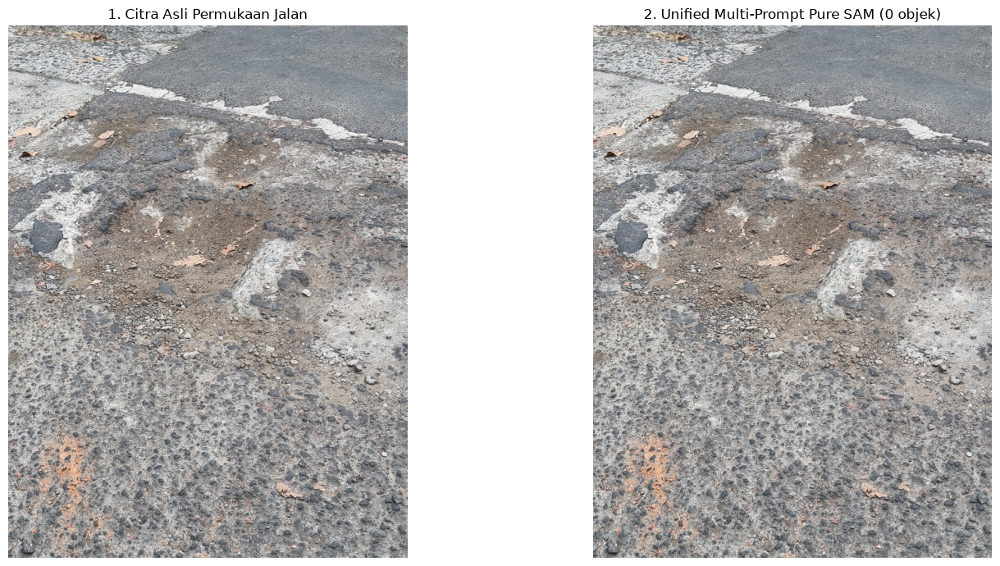

📊 Ringkasan Metrik per Kelas:
  ➖ Pothole (Lubang Jalan): tidak ditemukan pada gambar ini
  ➖ Manhole (Tutup Got): tidak ditemukan pada gambar ini
  ➖ Road Crack (Retakan Aspal): tidak ditemukan pada gambar ini
  ➖ Traffic Sign (Rambu Jalan): tidak ditemukan pada gambar ini


In [22]:
IMAGE_SAMPLE = "hard_image.png" if TEST_IMAGES else None

if IMAGE_SAMPLE:
    img_base = cv2.imread(IMAGE_SAMPLE)
    detections = run_prompt_detection(img_base, CLASS_PROMPTS)
    combined_overlay, unified_records = render_detections(img_base, detections)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(cv2.cvtColor(img_base, cv2.COLOR_BGR2RGB))
    axes[0].set_title("1. Citra Asli Permukaan Jalan", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(combined_overlay, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"2. Unified Multi-Prompt Pure SAM ({len(unified_records)} objek)", fontsize=12)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    print("📊 Ringkasan Metrik per Kelas:")
    for cls_name in CLASS_PROMPTS:
        cls_records = [r for r in unified_records if r["class"] == cls_name]
        if not cls_records:
            print(f"  ➖ {CLASS_PROMPTS[cls_name]['label']}: tidak ditemukan pada gambar ini")
            continue
        total_area_pct = sum(r["area_percent"] for r in cls_records)
        print(f"  ✅ {CLASS_PROMPTS[cls_name]['label']}: {len(cls_records)} instance, "
              f"total {total_area_pct:.2f}% dari luas gambar")
else:
    print("⚠️ Tidak ada gambar contoh di TEST_IMAGES untuk dijalankan.")
